In [1]:
import torch
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("./train.csv")

In [3]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
modes = df.mode().iloc[0]

In [5]:
df.fillna(modes, inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,B96 B98,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,B96 B98,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [7]:
df.describe(include=np.number)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

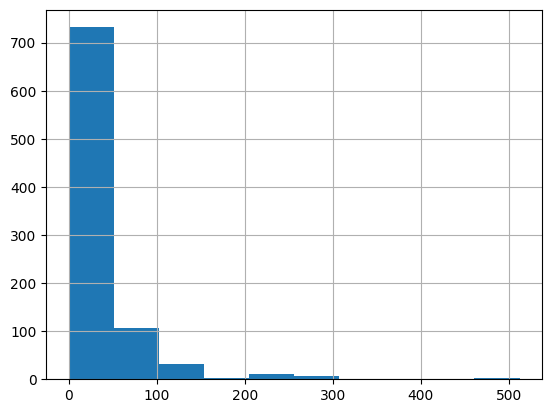

In [8]:
df["Fare"].hist()

In [9]:
df["LogFare"] = np.log(df["Fare"] + 1)

<Axes: >

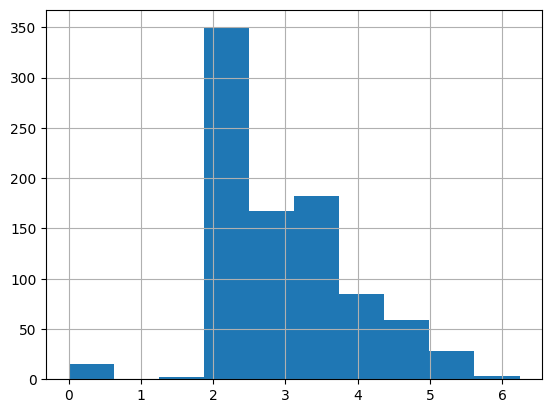

In [10]:
df["LogFare"].hist()

In [11]:
pclasses = sorted(df.Pclass.unique())
pclasses

[np.int64(1), np.int64(2), np.int64(3)]

In [12]:
df.describe(include=["object"])

C:\Users\user\AppData\Local\Temp\ipykernel_7956\3753758486.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object"])


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,691,646


In [13]:
df = pd.get_dummies(df, columns=["Sex", "Pclass", "Embarked"])

In [14]:
df.columns

Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'LogFare', 'Sex_female', 'Sex_male', 'Pclass_1',
       'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='str')

In [15]:
from torch import tensor

t_dep = tensor(df.Survived)

In [16]:
indep_cols = ["Age", "SibSp", "Parch", "LogFare", "Sex_male", "Sex_female", "Pclass_1", "Pclass_2", "Pclass_3", "Embarked_C", "Embarked_S", "Embarked_Q",]

t_indep = tensor(df[indep_cols].astype(float).values, dtype=torch.float)
t_indep

tensor([[22.,  1.,  0.,  ...,  0.,  1.,  0.],
        [38.,  1.,  0.,  ...,  1.,  0.,  0.],
        [26.,  0.,  0.,  ...,  0.,  1.,  0.],
        ...,
        [24.,  1.,  2.,  ...,  0.,  1.,  0.],
        [26.,  0.,  0.,  ...,  1.,  0.,  0.],
        [32.,  0.,  0.,  ...,  0.,  0.,  1.]])

In [17]:
t_indep.shape

torch.Size([891, 12])

In [18]:
torch.manual_seed(442)

n_coeffs = t_indep.shape[1]
coeffs = torch.rand(n_coeffs)-0.5
coeffs

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,
         0.2799, -0.4392,  0.2103,  0.3625])

In [19]:
t_indep*coeffs

tensor([[-10.1838,   0.1386,   0.0000,  ...,  -0.0000,   0.2103,   0.0000],
        [-17.5902,   0.1386,   0.0000,  ...,  -0.4392,   0.0000,   0.0000],
        [-12.0354,   0.0000,   0.0000,  ...,  -0.0000,   0.2103,   0.0000],
        ...,
        [-11.1096,   0.1386,   0.4818,  ...,  -0.0000,   0.2103,   0.0000],
        [-12.0354,   0.0000,   0.0000,  ...,  -0.4392,   0.0000,   0.0000],
        [-14.8128,   0.0000,   0.0000,  ...,  -0.0000,   0.0000,   0.3625]])

In [20]:
vals, indices = t_indep.max(dim=0)
t_indep = t_indep / vals

In [21]:
t_indep*coeffs

tensor([[-0.1273,  0.0173,  0.0000,  ..., -0.0000,  0.2103,  0.0000],
        [-0.2199,  0.0173,  0.0000,  ..., -0.4392,  0.0000,  0.0000],
        [-0.1504,  0.0000,  0.0000,  ..., -0.0000,  0.2103,  0.0000],
        ...,
        [-0.1389,  0.0173,  0.0803,  ..., -0.0000,  0.2103,  0.0000],
        [-0.1504,  0.0000,  0.0000,  ..., -0.4392,  0.0000,  0.0000],
        [-0.1852,  0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.3625]])

In [22]:
preds = (t_indep*coeffs).sum(axis=1)

In [23]:
(t_indep*coeffs).shape

torch.Size([891, 12])

In [24]:
preds[:10]

tensor([ 0.0405, -0.6239, -0.0543,  0.0534, -0.0554,  0.1589, -0.0216,  0.1953,
         0.0091, -0.6285])

In [25]:
loss = torch.abs(preds - t_dep).mean()
loss

tensor(0.5271)

In [26]:
def calc_preds(coeffs, indeps): return (coeffs*indeps).sum(axis=1)
def calc_loss(coeffs, indeps, deps): return torch.abs(calc_preds(coeffs, indeps) - deps).mean()

In [27]:
coeffs.requires_grad_()

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,
         0.2799, -0.4392,  0.2103,  0.3625], requires_grad=True)

In [28]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss

tensor(0.5271, grad_fn=<MeanBackward0>)

In [29]:
loss.backward()

In [30]:
coeffs.grad

tensor([-0.1640,  0.0020, -0.0116, -0.1901, -0.0685, -0.2716, -0.1459, -0.1167,
        -0.0774, -0.1886, -0.1639,  0.0123])

In [31]:
with torch.no_grad():
    coeffs.sub_(coeffs.grad * 0.1)
    print(calc_loss(coeffs, t_indep, t_dep))

tensor(0.5084)


In [32]:
from fastai.data.transforms import RandomSplitter

In [33]:
trn_split, val_split = RandomSplitter(seed=42)(df)

In [34]:
trn_indep, val_indep = t_indep[trn_split], t_indep[val_split]
trn_dep, val_dep = t_dep[trn_split], t_dep[val_split]
len(trn_indep), len(val_indep)

(713, 178)

In [35]:
def update_coeffs(coeffs, lr): coeffs.sub_(coeffs.grad * lr)

In [36]:
def one_epoch(coeffs, lr):
    loss = calc_loss(coeffs, trn_indep, trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"{loss:.3f}", end="; ")

In [40]:
def init_coeffs(): return (torch.rand(n_coeffs) - 0.5).requires_grad_()

In [38]:
def train_model(epochs=30, lr=0.01): 
    torch.manual_seed(442)
    coeffs = init_coeffs()
    for i in range(epochs): one_epoch(coeffs, lr)
    return coeffs

In [41]:
coeffs = train_model(18, 0.02)

0.525; 0.520; 0.512; 0.503; 0.494; 0.482; 0.468; 0.451; 0.431; 0.409; 0.385; 0.364; 0.346; 0.326; 0.305; 0.294; 0.300; 0.310; 

In [42]:
def show_coeffs(): return dict(zip(indep_cols, coeffs.requires_grad_(False)))
show_coeffs()

{'Age': tensor(-0.1919),
 'SibSp': tensor(0.1043),
 'Parch': tensor(0.2574),
 'LogFare': tensor(0.1276),
 'Sex_male': tensor(-0.4154),
 'Sex_female': tensor(0.3663),
 'Pclass_1': tensor(0.8761),
 'Pclass_2': tensor(0.4592),
 'Pclass_3': tensor(0.2746),
 'Embarked_C': tensor(0.1798),
 'Embarked_S': tensor(0.1668),
 'Embarked_Q': tensor(0.3158)}

In [43]:
preds = calc_preds(coeffs, val_indep)

In [45]:
results = val_dep.bool()==(preds>0.5)
results[:16]

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
        False, False, False,  True,  True,  True])

In [46]:
results.float().mean()

tensor(0.7753)

In [47]:
def acc(coeffs): return (val_dep.bool() == (calc_preds(coeffs, val_indep) > 0.5)).float().mean() 

In [48]:
acc(coeffs)

tensor(0.7753)

In [49]:
preds[:28]

tensor([ 1.1367,  0.1618,  0.0245,  0.2555,  0.2045,  0.2052,  0.9086,  0.9790,
         0.2537,  0.8835, -0.0060,  0.0944,  0.1234,  0.9438, -0.0144,  0.5873,
         0.5393,  1.0425,  0.1843,  0.7798,  0.0131,  0.5609,  1.4810,  1.0616,
         0.0207,  0.1965,  0.9123,  0.5465])

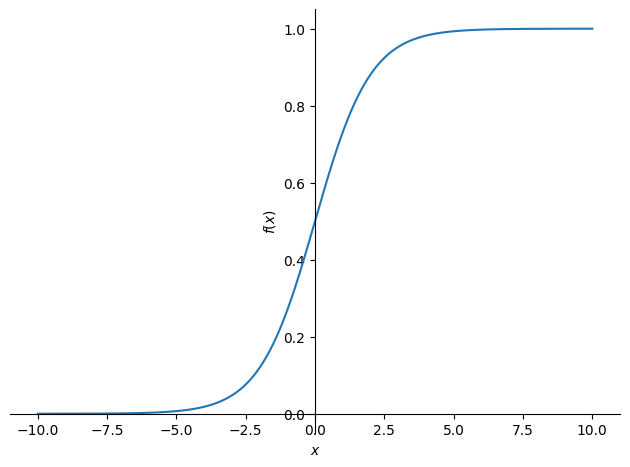

In [54]:
from sympy import symbols, exp
from sympy.plotting import plot
x = symbols("x")
sympy.plot(1/(1+exp(-x)), (x, -10, 10))

In [57]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps*coeffs).sum(axis=1))

In [58]:
coeffs = train_model(lr=2)

0.502; 0.460; 0.393; 0.340; 0.311; 0.289; 0.268; 0.247; 0.229; 0.217; 0.210; 0.206; 0.205; 0.204; 0.204; 0.205; 0.205; 0.206; 0.206; 0.206; 0.207; 0.206; 0.206; 0.206; 0.205; 0.204; 0.203; 0.202; 0.200; 0.199; 

In [59]:
acc(coeffs)

tensor(0.8258)

In [60]:
show_coeffs()

{'Age': tensor(-1.5616),
 'SibSp': tensor(-1.1865),
 'Parch': tensor(-0.0222),
 'LogFare': tensor(2.1263),
 'Sex_male': tensor(-18.5778),
 'Sex_female': tensor(16.4801),
 'Pclass_1': tensor(7.8216),
 'Pclass_2': tensor(4.1402),
 'Pclass_3': tensor(-12.4005),
 'Embarked_C': tensor(3.1239),
 'Embarked_S': tensor(-5.5819),
 'Embarked_Q': tensor(1.0719)}

In [66]:
test_df = pd.read_csv("test.csv")

In [67]:
test_df["Fare"] = test_df.Fare.fillna(0)

In [68]:
test_df.fillna(modes, inplace=True)
test_df["LogFare"] = np.log(test_df["Fare"] + 1)
test_df = pd.get_dummies(test_df, columns=["Sex", "Pclass", "Embarked"])

test_indep = tensor(test_df[indep_cols].astype(float).values, dtype=torch.float)
test_indep = test_indep / vals

In [69]:
test_df["Survived"] = (calc_preds(test_indep, coeffs)>0.5).int()

In [71]:
test_df.head()

,PassengerId,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,LogFare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S,Survived
0,892,"Kelly, Mr. James",34.5,0,0,330911,7.8292,B96 B98,2.178064,False,True,False,False,True,False,True,False,0
1,893,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,B96 B98,2.079442,True,False,False,False,True,False,False,True,0
2,894,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,B96 B98,2.369075,False,True,False,True,False,False,True,False,0
3,895,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,B96 B98,2.268252,False,True,False,False,True,False,False,True,0
4,896,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,B96 B98,2.586824,True,False,False,False,True,False,False,True,0


In [73]:
sub_df = test_df[["PassengerId", "Survived"]]
sub_df.to_csv("sub.csv", index=False)

In [74]:
def calc_preds(coeffs, indeps): return torch.sigmoid(indeps @ coeffs)

In [79]:
def init_coeffs(): return (torch.rand(n_coeffs, 1)*0.1).requires_grad_()

In [76]:
trn_dep = trn_dep[:, None]

In [77]:
val_dep = val_dep[:, None]

In [80]:
coeffs = train_model(lr=2)

0.512; 0.469; 0.393; 0.331; 0.300; 0.280; 0.263; 0.245; 0.229; 0.217; 0.210; 0.206; 0.204; 0.203; 0.203; 0.203; 0.203; 0.203; 0.204; 0.204; 0.204; 0.203; 0.203; 0.202; 0.202; 0.201; 0.199; 0.198; 0.197; 0.196; 

In [81]:
acc(coeffs
)

tensor(0.8258)

In [82]:
def init_coeffs(n_hidden=20):
    layer_1 = (torch.rand(n_coeffs, n_hidden) - 0.5) / n_hidden
    layer_2 = torch.rand(n_hidden, 1) - 0.3
    const = torch.rand(1)[0]
    return layer_1.requires_grad_(), layer_2.requires_grad_(), const.requires_grad_()

In [83]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    l1, l2, const = coeffs
    res = F.relu(indeps @ l1)
    res = res @ l2 + const
    return torch.sigmoid(res)
    

In [84]:
def update_coeffs(coeffs, lr): 
    for layer in coeffs: layer.sub_(layer.grad * lr)

In [85]:
coeffs = train_model(lr=1.4)

0.543; 0.533; 0.512; 0.471; 0.404; 0.319; 0.263; 0.233; 0.213; 0.207; 0.206; 0.205; 0.201; 0.195; 0.193; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.191; 0.191; 0.191; 0.191; 0.191; 0.191; 0.191; 

In [86]:
acc(coeffs)

tensor(0.8258)

In [87]:
def init_coeffs():
    hiddens = [10, 10]
    sizes = [n_coeffs] + hiddens + [1]
    n = len(sizes)
    layers = [(torch.rand(sizes[i], sizes[i+1]) - 0.3) / sizes[i+1]*4 for i in range(n-1)]
    consts = [(torch.rand(1)[0] - 0.5) * 0.1 for i in range(n-1)]
    for l in layers+consts: l.requires_grad_()
    return layers, consts

In [93]:
def calc_preds(coeffs, indeps):
    layers, consts = coeffs
    n = len(layers)
    res = indeps
    for i, l in enumerate(layers):
        res = res @ l + consts[i] 
        if i != n-1: res = F.relu(res)
    return torch.sigmoid(res)

In [94]:
def update_coeffs(coeffs, lr):
    layers, consts = coeffs
    for layer in layers+consts: layer.sub_(layer.grad * lr)

In [98]:
coeffs = train_model(lr=1.3)

0.533; 0.476; 0.394; 0.323; 0.230; 0.219; 0.225; 0.227; 0.227; 0.226; 0.225; 0.220; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 0.215; 

In [99]:
acc(coeffs)

tensor(0.7921)